In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import boto3
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2024-12-16 21:10:31.355746


#### Functions

In [3]:
# download from s3
def download_from_s3(str_local_path, str_bucket_path, str_project):
    # init client
    cls_client = boto3.client(
        's3',
    )
    # download file
    cls_client.download_file(
        str_project, 
        str_bucket_path, 
        str_local_path,
    )

#### Constants

In [4]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

flt_factor_24_to_72 = 2.36

Project: 20241112-simple-model-test
Task: 09_15_in_60


#### Make output directory

In [5]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [6]:
str_filename = 'df.gzip'
str_uri = f's3://{str_project}/parse_all_apps/02_parse_payloads/{str_filename}'
df = pd.read_parquet(str_uri)
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,flt_past_due__tu_pmthx,flt_30_dpd__tu_pmthx,flt_60_dpd__tu_pmthx,flt_90_dpd__tu_pmthx,str_loan_type__tu_pmthx,str_pmt_hx__tu_pmthx,str_dtm_most_recent_pmt__tu_pmthx,str_method__tu_pmthx,auto__tu_pmthx,flt_sec
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493,10452716,1,Ohio,...,"[252.0, 486.0, 250.0, 2000.0, 0.0, 3076.0, 0.0...","[1.0, 1.0, 1.0, 1.0, 2.0, 1.0, 0.0, nan, nan, ...","[1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, nan, nan, ...","[0.0, 2.0, 0.0, 4.0, 0.0, 2.0, 0.0, nan, nan, ...","['LC', 'CC', 'CC', 'AU', 'AU', 'AU', 'SC', 'ST...","['LLLLLLLLLLLLLLLL321', 'LLLLLLLLLLLLLLLLLLLLL...","[nan, nan, nan, '2024-01-29', '2020-01-02', '2...","['automated', 'automated', 'automated', 'autom...","[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]",0.161885
0,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030,10419180,1,Virginia,...,"[482.0, 11924.0, 0.0, 15.0, 0.0, 0.0, 0.0, 0.0...","[3.0, 2.0, 2.0, 1.0, 0.0, 3.0, 0.0, 1.0, 0.0, ...","[1.0, 1.0, 2.0, 1.0, 0.0, 1.0, 0.0, 2.0, 0.0, ...","[1.0, 1.0, 4.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","['AU', 'US', 'CH', 'CC', 'CC', 'CC', 'CC', 'CC...",['LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL4322211111111...,"['2021-12-29', '2022-02-25', '2023-02-23', '20...","['automated', 'automated', 'automated', 'autom...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.102787
0,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326,10415994,1,Utah,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,0.075270
0,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439,10446729,1,Texas,...,"[121.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[1.0, 0.0, nan, 0.0, 1.0, 1.0, 1.0]","[1.0, 0.0, nan, 0.0, 0.0, 1.0, 0.0]","[0.0, 30.0, nan, 0.0, 0.0, 0.0, 0.0]","['CC', 'CP', 'SC', 'LC', 'SE', 'SE', 'SE']","['3211', '1155555555555555555Y5555555555555', ...","[nan, '2024-09-30', nan, '2024-09-24', '2022-0...","['automated', 'automated', 'automated', 'autom...","[0, 0, 0, 0, 0, 0, 0]",0.095339
0,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168,10441665,1,Colorado,...,"[3600.0, 0.0, 366.0, 0.0, 498.0, 0.0, 0.0, 0.0...","[4.0, 2.0, 0.0, 2.0, 2.0, 13.0, 0.0, 0.0, 0.0,...","[3.0, 2.0, 0.0, 3.0, 1.0, 7.0, 0.0, 0.0, 0.0, ...","[2.0, 4.0, 0.0, 2.0, 0.0, 5.0, 0.0, 0.0, 0.0, ...","['AU', 'CH', 'CU', 'SE', 'NT', 'AU', 'AU', 'US...",['LLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLLL...,"['2022-03-18', '2019-10-13', nan, '2021-08-10'...","['automated', 'automated', 'automated', 'autom...","[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.097532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164,10397758,1,Kansas,...,"[0.0, nan, nan, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","['US', 'FR', 'LC', 'CC', 'CC', 'CC', 'CC', 'CC...","['32111', 'XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX...","['2021-11-05', '2024-10-25', '2019-01-18', '20...","['automated', 'automated', 'automated', 'autom...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.100632
0,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216,10418204,1,Alabama,...,"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","['SE', 'CC', 'SE']","['111', '1E', '1']","['2024-10-25', '2024-11-04', '2024-06-28']","['automated', 'automated', 'automated']","[0, 0, 0]",0.095197
0,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-X

#### Import preprocessor

In [7]:
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in list_str_filename:
    str_bucket_path = f'01_ad/02_model/noPTImodel10/00_preprocessing/01_create_preprocessor/{str_filename}'
    str_local_path = f'./{str_filename}'
    download_from_s3(
        str_local_path=str_local_path,
        str_bucket_path=str_bucket_path,
        str_project='20231010-gen-xii',
    )
cls_model_preprocessing = pickle.load(open(str_local_path, 'rb'))

#### Preprocess data

In [8]:
df = cls_model_preprocessing.transform(df)
# rm
list_str_filename = [
    'preprocessing.py',
    'cls_model_preprocessing.pkl',
]
for str_filename in tqdm(list_str_filename):
    os.remove(str_filename)
# show
df

NaN Replacer: 0.019045 sec.


100%|██████████| 3/3 [00:00<00:00, 1548.67it/s]

Unable to convert vehiclemodel__app to string, not found in data
Set strings: 0.0042351 sec.
Boolean Replacer: 0.029745 sec.



100%|██████████| 1936/1936 [00:00<00:00, 4966.84it/s]


Data Type Setter: 0.83131 sec.


...

Replace inf and -inf with NaN: 1.0014 sec.
Imputer: 0.055437 sec.
Map term: 0.0016702 sec.
Map PTI: 0.0009584 sec.


100%|██████████| 6/6 [00:00<00:00, 2220.97it/s]


Round values: 0.0061771 sec.
Preprocessing Model: 2.8081 sec.


100%|██████████| 2/2 [00:00<00:00, 3919.91it/s]


,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,auto__tu_pmthx,flt_sec,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493.0,10452716.0,1.0,ohio,...,"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1]",0.161885,2024,0.9409,12,4,0.06,1.068182,-1.0,4.860274
0,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030.0,10419180.0,1.0,virginia,...,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, ...",0.102787,2024,0.9409,12,4,0.06,1.200000,3.0,2.931507
0,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326.0,10415994.0,1.0,utah,...,0,0.075270,2024,0.9409,11,4,0.15,0.842105,4.0,21.413699
0,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439.0,10446729.0,1.0,texas,...,"[0, 0, 0, 0, 0, 0, 0]",0.095339,2024,0.9409,12,4,0.12,1.119048,3.0,0.819178
0,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168.0,10441665.0,1.0,colorado,...,"[1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]",0.097532,2024,0.9409,12,4,0.06,1.071429,3.0,2.991781
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164.0,10397758.0,1.0,kansas,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.100632,2024,0.9409,11,4,0.09,1.333333,4.0,12.063014
0,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216.0,10418204.0,1.0,alabama,...,"[0, 0, 0]",0.095197,2024,0.9409,12,4,0.15,1.139535,-1.0,11.463014
0,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,8437017/tSV8-2024-12-02-14:58:04,1,8437017104168181,8437017.0,10416818.0,1.0,michigan,...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.094234,2024,0.9409,12,4,0.15,1.250000,2.0,7.276712
0,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,8469931/1vC4-2024-12-07-01:07:56,1,8469931104520491,8469931.0,10452049.0,1.0,california,...,"[1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.094273,2024,0.9409,12,4,0.06,1.163934,5.0,6.904110


#### PD predictions

In [9]:
str_filename = 'final_model.pkl'
str_model = '02_pricing_pd'
str_bucket_path = f'{str_model}/02_model/noPTImodel10/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20231010-gen-xii',
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['pd'] = cls_model_inference.predict_proba(df[list_cols_model])[:,1]
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,flt_sec,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493.0,10452716.0,1.0,ohio,...,0.161885,2024,0.9409,12,4,0.06,1.068182,-1.0,4.860274,0.189789
0,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030.0,10419180.0,1.0,virginia,...,0.102787,2024,0.9409,12,4,0.06,1.200000,3.0,2.931507,0.308459
0,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326.0,10415994.0,1.0,utah,...,0.075270,2024,0.9409,11,4,0.15,0.842105,4.0,21.413699,0.210214
0,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439.0,10446729.0,1.0,texas,...,0.095339,2024,0.9409,12,4,0.12,1.119048,3.0,0.819178,0.394319
0,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168.0,10441665.0,1.0,colorado,...,0.097532,2024,0.9409,12,4,0.06,1.071429,3.0,2.991781,0.189594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164.0,10397758.0,1.0,kansas,...,0.100632,2024,0.9409,11,4,0.09,1.333333,4.0,12.063014,0.081558
0,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216.0,10418204.0,1.0,alabama,...,0.095197,2024,0.9409,12,4,0.15,1.139535,-1.0,11.463014,0.412814
0,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,8437017/tSV8-2024-12-02-14:58:04,1,8437017104168181,8437017.0,10416818.0,1.0,michigan,...,0.094234,2024,0.9409,12,4,0.15,1.250000,2.0,7.276712,0.249974
0,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,8469931/1vC4-2024-12-07-01:07:56,1,8469931104520491,8469931.0,10452049.0,1.0,california,...,0.094273,2024,0.9409,12,4,0.06,1.163934,5.0,6.904110,0.144825


#### LGD predictions

In [10]:
str_filename = 'final_model.pkl'
str_model = '03_pricing_lgd'
str_bucket_path = f'{str_model}/02_model/noPTImodel10/03_final_model/{str_filename}'
str_local_path = f'./{str_filename}'
download_from_s3(
    str_local_path=str_local_path,
    str_bucket_path=str_bucket_path,
    str_project='20231010-gen-xii',
)
cls_model_inference = pickle.load(open(str_local_path, 'rb'))['model_inference']
os.remove(str_local_path)
# predict
list_cols_model = list(cls_model_inference.feature_names_)
df['lgd'] = cls_model_inference.predict(df[list_cols_model])
# show
df

,accountid,request_datetime,response_model_name,file_name,bitdebtor,uniqueid__app,bigaccountid__app,bigdebtorid__app,bitdebtor__app,dealerstate__app,...,year,factor,ENG-applicationdate__app_month,ENG-applicationdate__app_quarter,ENG-payment_to_income,ENG-loan_to_value,ENG-vehicle_age,ENG-dealership_age,pd,lgd
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,8470493/VtvM-2024-12-07-16:22:29,1,8470493104527161,8470493.0,10452716.0,1.0,ohio,...,2024,0.9409,12,4,0.06,1.068182,-1.0,4.860274,0.189789,0.663703
0,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,8439030/oGh5-2024-12-02-22:56:13,1,8439030104191801,8439030.0,10419180.0,1.0,virginia,...,2024,0.9409,12,4,0.06,1.200000,3.0,2.931507,0.308459,0.568339
0,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,8436326/aA1E-2024-12-01-00:03:43,1,8436326104159941,8436326.0,10415994.0,1.0,utah,...,2024,0.9409,11,4,0.15,0.842105,4.0,21.413699,0.210214,0.656715
0,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,8465439/V560-2024-12-05-18:22:52,1,8465439104467291,8465439.0,10446729.0,1.0,texas,...,2024,0.9409,12,4,0.12,1.119048,3.0,0.819178,0.394319,0.706693
0,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,8461168/aIDo-2024-12-03-21:09:47,1,8461168104416651,8461168.0,10441665.0,1.0,colorado,...,2024,0.9409,12,4,0.06,1.071429,3.0,2.991781,0.189594,0.617701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,8421164/on2a-2024-12-03-16:21:54,1,8421164103977581,8421164.0,10397758.0,1.0,kansas,...,2024,0.9409,11,4,0.09,1.333333,4.0,12.063014,0.081558,0.677647
0,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,8438216/202q-2024-12-02-20:14:37,1,8438216104182041,8438216.0,10418204.0,1.0,alabama,...,2024,0.9409,12,4,0.15,1.139535,-1.0,11.463014,0.412814,0.711134
0,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,8437017/tSV8-2024-12-02-14:58:04,1,8437017104168181,8437017.0,10416818.0,1.0,michigan,...,2024,0.9409,12,4,0.15,1.250000,2.0,7.276712,0.249974,0.724405
0,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,8469931/1vC4-2024-12-07-01:07:56,1,8469931104520491,8469931.0,10452049.0,1.0,california,...,2024,0.9409,12,4,0.06,1.163934,5.0,6.904110,0.144825,0.649104


#### Subset

In [11]:
list_cols = [
    'accountid',
    'request_datetime',
    'response_model_name',
    'bitdebtor',
    'pd',
    'lgd',
]
df = df[list_cols].copy()
# show
df

,accountid,request_datetime,response_model_name,bitdebtor,pd,lgd
0,8470493,2024-12-07 23:22:29+00:00,PRESTIGE-GEN-XII,1,0.189789,0.663703
0,8439030,2024-12-03 05:56:13+00:00,PRESTIGE-GEN-XII,1,0.308459,0.568339
0,8436326,2024-12-01 07:03:43+00:00,PRESTIGE-GEN-XII,1,0.210214,0.656715
0,8465439,2024-12-06 01:22:52+00:00,PRESTIGE-GEN-XII,1,0.394319,0.706693
0,8461168,2024-12-04 04:09:47+00:00,PRESTIGE-GEN-XII,1,0.189594,0.617701
...,...,...,...,...,...,...
0,8421164,2024-12-03 23:21:54+00:00,PRESTIGE-GEN-XII,1,0.081558,0.677647
0,8438216,2024-12-03 03:14:37+00:00,PRESTIGE-GEN-XII,1,0.412814,0.711134
0,8437017,2024-12-02 21:58:04+00:00,PRESTIGE-GEN-XII,1,0.249974,0.724405
0,8469931,2024-12-07 08:07:56+00:00,PRESTIGE-GEN-XII,1,0.144825,0.649104


#### Save locally

In [12]:
%%time

str_filename = 'df_predictions.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_parquet(str_local_path, compression='gzip')

CPU times: user 7.12 ms, sys: 180 μs, total: 7.3 ms
Wall time: 6.34 ms


#### Group by account

In [13]:
df_tmp = df.groupby(by='accountid', as_index=False).agg({
    'request_datetime': 'last',
    'response_model_name': 'last',
    'pd': 'mean',
    'lgd': 'mean',
})
# get ecnl
df_tmp['ecnl'] = df_tmp['pd'] * df_tmp['lgd'] * flt_factor_24_to_72 # factor to go from 24 to 72 months loss
# show
df_tmp

,accountid,request_datetime,response_model_name,pd,lgd,ecnl
0,8211697,2024-12-08 01:38:28+00:00,PRESTIGE-GEN-XII,0.169426,0.622071,0.248733
1,8315912,2024-12-04 00:16:24+00:00,PRESTIGE-GEN-XII,0.030895,0.626268,0.045663
2,8323560,2024-12-06 00:45:28+00:00,PRESTIGE-GEN-XII,0.167438,0.700664,0.276869
3,8332159,2024-12-06 23:32:31+00:00,PRESTIGE-GEN-XII,0.175550,0.685440,0.283977
4,8337838,2024-12-05 01:21:04+00:00,PRESTIGE-GEN-XII,0.045893,0.730413,0.079110
...,...,...,...,...,...,...
995,8472730,2024-12-08 06:33:43+00:00,PRESTIGE-GEN-XII,0.255127,0.575841,0.346713
996,8472731,2024-12-08 06:33:47+00:00,PRESTIGE-GEN-XII,0.408038,0.635713,0.612172
997,8472750,2024-12-08 06:41:36+00:00,PRESTIGE-GEN-XII,0.235176,0.623606,0.346111
998,8472773,2024-12-08 06:51:07+00:00,PRESTIGE-GEN-XII,0.349750,0.655796,0.541301


#### Save locally

In [14]:
%%time

str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tmp.to_parquet(str_local_path, compression='gzip')

CPU times: user 3.58 ms, sys: 4.01 ms, total: 7.59 ms
Wall time: 6.22 ms


#### Distribution

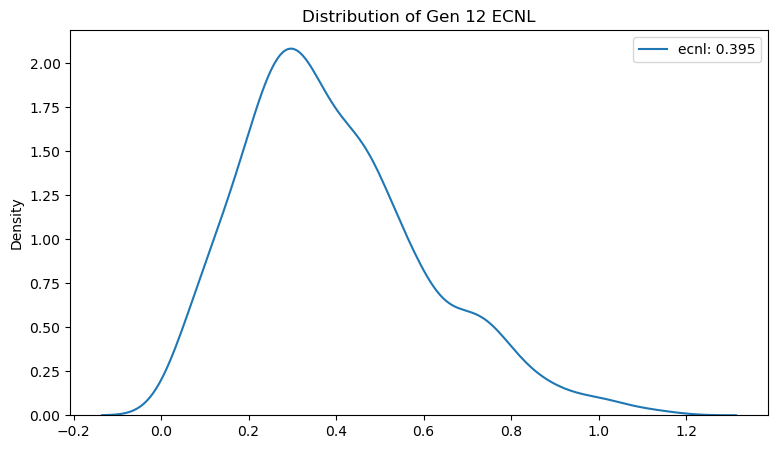

In [15]:
col = 'ecnl'
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distribution of Gen 12 ECNL')
flt_mn = df_tmp[col].mean()
str_label = f'{col}: {flt_mn:0.3f}'
sns.kdeplot(list(df_tmp[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()

#### Get quantiles

In [16]:
list_cols = [
    'ecnl',
]
for col in tqdm(list_cols):
    # ml
    arr_score_quantiles = np.percentile(
        list(df_tmp[col]),
        np.linspace(0, 100, 100),
    )
    # save
    str_filename = f'arr_score_quantiles_{col}.pkl'
    str_local_path = f'{str_dirname_output}/{str_filename}'
    pickle.dump(arr_score_quantiles, open(str_local_path, 'wb'))

100%|██████████| 1/1 [00:00<00:00, 1107.55it/s]
